# Loading and Cleaning the Dataset

## 1. Load and Inspect Dataset

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('xy_data.csv')


print(f"+{'-'*60}+")
print("Raw Data")
print(f"+{'-'*60}+")

print("First 5 rows:\n")
print(df.head())

print("\nData Types")
print(df.dtypes)

print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


+------------------------------------------------------------+
Raw Data
+------------------------------------------------------------+
First 5 rows:

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Data Types
x    float64
y    float64
dtype: object

Shape: (1500, 2)
Columns: ['x', 'y']


## 2. Check for Missing Values

In [5]:
print(f"+{'-'*60}+")
print("Missing Values Check")
print(f"+{'-'*60}+")

missing_values_columnwise = df[['x', 'y']].isna().sum()
print(missing_values_columnwise)

if missing_values_columnwise.sum() > 0:
    print("\nHandling missing values...")

df = df.dropna(subset=["x", "y"]).reset_index(drop=True)

+------------------------------------------------------------+
Missing Values Check
+------------------------------------------------------------+
x    0
y    0
dtype: int64


## 3. Check for Duplicates

In [7]:
print(f"+{'-'*60}+")
print("Duplicates Check")
print(f"+{'-'*60}+")

xy_duplicates = df.duplicated(subset=["x", "y"]).sum()

print(f"Duplicate (x, y) coordinates: {xy_duplicates}")

if xy_duplicates > 0:
    df = df.drop_duplicates(subset=["x", "y"], keep="first").reset_index(drop=True)

+------------------------------------------------------------+
Duplicates Check
+------------------------------------------------------------+
Duplicate (x, y) coordinates: 0


## 4. Extract Clean Numpy Arrays

In [9]:
x_data = df["x"].to_numpy(dtype=float)
y_data = df["y"].to_numpy(dtype=float)

## 5. Final Clean Dataset

In [11]:
print(f"+{'-'*60}+")
print("Parameter Estimation")
print(f"+{'-'*60}+")

print(f"No. of Observations: {len(df)}")

print("\nX range:")
print(f"{x_data.min():.10f} - {x_data.max():.10f}")

print("\nY range:")
print(f"{y_data.min():.10f} - {y_data.max():.10f}")

+------------------------------------------------------------+
Parameter Estimation
+------------------------------------------------------------+
No. of Observations: 1500

X range:
59.6572040000 - 109.2315200000

Y range:
46.0322950000 - 69.6855100000


# Mathematical Transformation

## 6. Parametric Curve Transformation

```
x = t * cos(theta) - exp(M|t|) * sin(0.3t)sin(theta) + X 
=> x - X = t * cos(theta) - exp(M|t|) * sin(0.3t)sin(theta)

y = 42 + t * sin(theta) + exp(M|t|) * sin(0.3t)cos(theta)
=> y - 42 = t * sin(theta) + exp(M|t|) * sin(0.3t)cos(theta)

Let d = exp(M|t|) * sin(0.3t); where, d = Observed Displacement

Thus, on simplification, 
(x - X)cos(theta) + (y - 42)sin(theta)
=> (t * cos(theta) - d * sin(theta))cos(theta) + (t * sin(theta) + d * cos(theta))sin(theta)
=> t

Therefore, (x - X)cos(theta) + (y - 42)sin(theta) = t

Thus, on simplification,
-(x - X)sin(theta) + (y - 42)cos(theta)
=> -(t * cos(theta) - d * sin(theta))sin(theta) + (t * sin(theta) + d * cos(theta))cos(theta)
=> d
```

In [15]:
def transform_coordinates(x, y, theta, X):
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    # ----- Translation -----
    dx = x - X
    dy = y - 42.0

    # ---- Projection -----
    t = dx * cos_theta + dy * sin_theta
    observed_displacement = -dx * sin_theta + dy * cos_theta

    return t, observed_displacement

## 7. Theoretical Oscillation

In [17]:
def theoretical_displacement(t, M):
    # Since, we are given 6 < t < 60
    # Thus, |t| = t

    return np.exp(M * t) * np.sin(0.3 * t)
    

## 8. Implement the Complete Transformation

In [19]:
def apply_transformations(x, y, theta, M, X):
    # Transform Cartesian coordinates
    t, observed = transform_coordinates(x, y, theta, X)

    # Calculate theoretical displacement
    predicted = theoretical_displacement(t, M)

    return t, observed, predicted

## 9. Test the Transformation

In [21]:
import numpy as np

theta_test = np.radians(30.0)
M_test = 0.03
X_test = 55.0

t_test, observed_test, predicted_test = apply_transformations(x_data, y_data, theta_test, M_test, X_test)

print(f"+{'-'*60}+")
print("Transformation Test")
print(f"+{'-'*60}+")

print(f"t Range: \n{t_test.min():.4f} - {t_test.max():.10f}")
print(f"\nObserved Displacement Range: \n{observed_test.min():.10f} - {observed_test.max():.10f}")
print(f"\nPredicted Displacement Range: \n{predicted_test.min():.10f} - {predicted_test.max():.10f}")

+------------------------------------------------------------+
Transformation Test
+------------------------------------------------------------+
t Range: 
6.0494 - 59.9951670058

Observed Displacement Range: 
-5.6568793866 - 4.1317546688

Predicted Displacement Range: 
-5.6568491972 - 4.1317778546


## 10. Validate Recovered t

In [23]:
valid_t_mask = (t_test > 6) & (t_test < 60)

print(f"+{'-'*60}+")
print("t-range Validation")
print(f"+{'-'*60}+")

print(f"Valid t values: \n{valid_t_mask.sum()} / {len(t_test)}")
print(f"Invalid t values: \n{(~valid_t_mask).sum()}")

if (~valid_t_mask).sum() > 0:
    print("Warning: Some recovered t values are outside the allowed range")

else:
    print("All recovered t values satisfy 6 < t < 60")

+------------------------------------------------------------+
t-range Validation
+------------------------------------------------------------+
Valid t values: 
1500 / 1500
Invalid t values: 
0
All recovered t values satisfy 6 < t < 60


## 11. Calculate Residuals

In [25]:
def calculate_residuals(params, x, y):
    theta, M, X = params

    # ----- Transform Observed Coordinates -----
    t, observed, predicted = apply_transformations(x, y, theta, M, X)

    # ----- Residual -----
    residual = observed - predicted

    return residual

### Test Residuals

In [27]:
test_params = [np.radians(30.0), 0.03, 55.0]

residual_test = calculate_residuals(
    test_params,
    x_data,
    y_data
)

print(f"+{'-'*60}+")
print("Residual Test")
print(f"+{'-'*60}+")

print(f"Mean Absolute Residual: {np.mean(np.abs(residual_test)):.10f}")
print(f"Maximum Absolute Residual: {np.max(np.abs(residual_test)):.10f}")
print(f"L1 Residual: {np.sum(np.abs(residual_test)):.10f}")

+------------------------------------------------------------+
Residual Test
+------------------------------------------------------------+
Mean Absolute Residual: 0.0000150483
Maximum Absolute Residual: 0.0000405114
L1 Residual: 0.0225724051


# Optimisation

## 12. L1 Objective Function

In [30]:
from scipy.optimize import differential_evolution

def objective_function(params):
    residuals = calculate_residuals(params, x_data, y_data)

    return np.sum(np.abs(residuals))

## 13. Parameter Bounds and Global Optimisation

In [32]:
parameter_bounds = [
    (np.radians(0.000001), np.radians(49.999999)),   # theta
    (-0.049999999, 0.049999999),                     # M
    (0.000001, 99.999999 )                           # X
]

result = differential_evolution(objective_function, parameter_bounds, seed=42, tol=1e-10, polish=True, workers=1)

## 14. Extract Parameters

In [34]:
theta_opt, M_opt, X_opt = result.x

theta_degs = np.degrees(theta_opt)

print(f"+{'-'*60}+")
print("Optimisation Result")
print(f"+{'-'*60}+")

print(f"Success: {result.success}")
print(f"Message: {result.message}")

print("\nEstimated parameters:")
print(f"theta = {theta_degs:.10f} degrees")
print(f"M = {M_opt:.10f}")
print(f"X = {X_opt:.10f}")

print(f"\nObjective (L1): {result.fun:.10f}")

+------------------------------------------------------------+
Optimisation Result
+------------------------------------------------------------+
Success: True
Message: Optimization terminated successfully.

Estimated parameters:
theta = 29.9999730015 degrees
M = 0.0299999971
X = 54.9999983399

Objective (L1): 0.0038378897


## 15. Validate Optimised Parameters

In [36]:
t_opt, observed_opt, predicted_opt = apply_transformations(x_data, y_data, theta_opt, M_opt, X_opt)

residual_opt = observed_opt- predicted_opt

print(f"+{'-'*60}+")
print("Optimised Transformation")
print(f"+{'-'*60}+")

print(f"Recovered t Range: {t_opt.min():.10f} - {t_opt.max():.10f}")
print(f"Mean Absolute Residual: {np.mean(np.abs(residual_opt)):.10f}")
print(f"Maximum Absolute Residual: {np.max(np.abs(residual_opt)):.10f}")
print(f"L1 Residual: {np.sum(np.abs(residual_opt)):.10f}")

+------------------------------------------------------------+
Optimised Transformation
+------------------------------------------------------------+
Recovered t Range: 6.0494053641 - 59.9951705868
Mean Absolute Residual: 0.0000025586
Maximum Absolute Residual: 0.0000174587
L1 Residual: 0.0038378897


## 16. Validate t Range

In [38]:
valid_t = (t_opt > 6) & (t_opt < 60)

print(f"+{'-'*60}+")
print("t Constraint")
print(f"+{'-'*60}+")

print(f"Valid points: {valid_t.sum()}")
print(f"Invalid points: {(~valid_t).sum()}")

if valid_t.all():
    print("Pass: All recovered t values satisfy 6 < t < 60")
else:
    print("Fail: Some recovered t values violate 6 < t < 60")

+------------------------------------------------------------+
t Constraint
+------------------------------------------------------------+
Valid points: 1500
Invalid points: 0
Pass: All recovered t values satisfy 6 < t < 60


# Final Curve Reconstruction anf Validation

## 17. Original Parametric Curve

In [41]:
def parametric_curve(t, theta, M, X):
    # Since, 6 < t < 60
    # |t| = t
    abs_t = np.abs(t)

    x = t * np.cos(theta) - np.exp(M * abs_t) * np.sin(0.3 * t) * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + np.exp(M * abs_t) * np.sin(0.3 * t) * np.cos(theta)

    return x, y

## 18. Generate Uniformly Sampled Curve

+------------------------------------------------------------+
Generated Curve
+------------------------------------------------------------+
No. of samples: 10000
t Range: 6.000001 - 59.999999


Visulation:


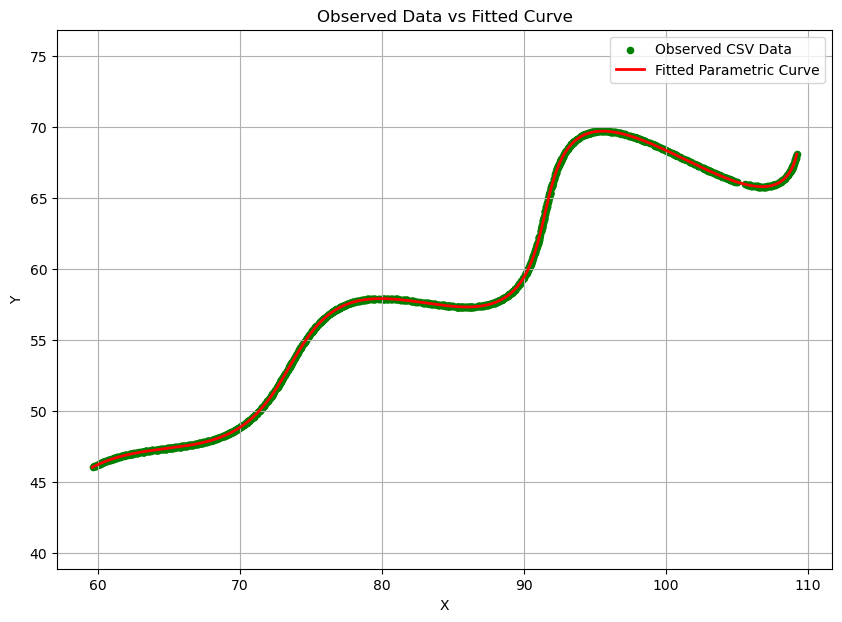

In [43]:
import matplotlib.pyplot as plt

SAMPLES = 10000

t_uni = np.linspace(6.000001, 59.999999, SAMPLES)

x_curve, y_curve = parametric_curve(t_uni, theta_opt, M_opt, X_opt)

print(f"+{'-'*60}+")
print("Generated Curve")
print(f"+{'-'*60}+")

print(f"No. of samples: {SAMPLES}")
print(f"t Range: {t_uni.min():.6f} - {t_uni.max():.6f}\n")

print("\nVisulation:")
plt.figure(figsize=(10, 7))

plt.scatter(x_data, y_data, s=20, c="green", label="Observed CSV Data")
plt.plot(x_curve, y_curve, "r-", linewidth=2, label="Fitted Parametric Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Observed Data vs Fitted Curve")

plt.legend()
plt.grid(True)
plt.axis("equal")

plt.show()

## 19. Recover t for Observed Data

In [45]:
t_observed = (x_data - X_opt) * np.cos(theta_opt) + (y_data - 42.0) * np.sin(theta_opt)

print(f"+{'-'*60}+")
print("Observed t Values")
print(f"+{'-'*60}+")

print(f"t Range: {t_observed.min():.10f} - {t_observed.max():.10f}")

+------------------------------------------------------------+
Observed t Values
+------------------------------------------------------------+
t Range: 6.0494053641 - 59.9951705868


## 20. Reconstruct Observed Points

In [47]:
x_reconstruct, y_reconstruct = parametric_curve(t_observed, theta_opt, M_opt, X_opt)

x_error = x_data - x_reconstruct
y_error = y_data - y_reconstruct

print(f"+{'-'*60}+")
print("Reconstuction Error")
print(f"+{'-'*60}+")

print(f"Mean |x Error|: {np.mean(np.abs(x_error)):.12f}")
print(f"Mean |y Error|: {np.mean(np.abs(y_error)):.12f}")
print(f"Maximum |x Error|: {np.max(np.abs(x_error)):.12f}")
print(f"Maximum |y Error|: {np.max(np.abs(y_error)):.12f}")

+------------------------------------------------------------+
Reconstuction Error
+------------------------------------------------------------+
Mean |x Error|: 0.000001279296
Mean |y Error|: 0.000002215807
Maximum |x Error|: 0.000008729327
Maximum |y Error|: 0.000015119655


## 21. Point-wise L1 Error

In [49]:
pointwise_l1 = np.abs(x_error) + np.abs(y_error)

total_l1 = np.sum(pointwise_l1)
mean_l1 = np.mean(pointwise_l1)

print(f"+{'-'*60}+")
print("L1 Error")
print(f"+{'-'*60}+")

print(f"Total L1 Error: {total_l1:.12f}")
print(f"Mean L1 Error: {mean_l1:.12f}")

+------------------------------------------------------------+
L1 Error
+------------------------------------------------------------+
Total L1 Error: 0.005242654120
Mean L1 Error: 0.000003495103


## 22. Final Parameter Validation

In [51]:
print(f"+{'-'*60}+")
print("Final Parameters")
print(f"+{'-'*60}+")

print(f"Theta = {np.degrees(theta_opt):.8f} degrees")
print(f"M = {M_opt:.10f}")
print(f"X = {X_opt:.8f}")

print("\nParameter constraints:")

theta_valid = 0 < np.degrees(theta_opt) < 50
M_valid = -0.05 < M_opt < 0.05
X_valid = 0 < X_opt < 100
t_valid = np.all((t_observed > 6) & (t_observed < 60))

print(f"Theta Constraint: {'Pass' if theta_valid else 'Fail'}")
print(f"M Constraint: {'Pass' if M_valid else 'Fail'}")
print(f"X Constraint: {'Pass' if X_valid else 'Fail'}")
print(f"t Constraint: {'Pass' if t_valid else 'Fail'}")

+------------------------------------------------------------+
Final Parameters
+------------------------------------------------------------+
Theta = 29.99997300 degrees
M = 0.0299999971
X = 54.99999834

Parameter constraints:
Theta Constraint: Pass
M Constraint: Pass
X Constraint: Pass
t Constraint: Pass
